# Propagule size tracking from RBG image

## 1. Documentation and Imports


Created on 17-02-2021

Author: Valentin Laplaud

This code will load time series of propagules image in color, identify the propagule, and measure its size in time.

In [1]:

# plotting stuff
import matplotlib as mpl
import matplotlib.pyplot as plt

# numbers handling
import numpy as np
import pandas as pd

# images handling
from skimage import io
from skimage.filters import threshold_otsu, gaussian
from skimage.measure import label, regionprops_table
from skimage.util import invert
from skimage.morphology import binary_opening, binary_closing, remove_small_holes

# to hide known warnings
import warnings

# General system functions
import os
import shutil
import sys

import time

# my functions
sys.path.append('../')
import VallapFunc as vf

## 2. Define data processing functions



### 2.0 Create binary circle element for image processing

In [2]:
def create_circular_mask(h, w, center=None, radius=None):

    if center is None: # use the middle of the image
        center = (int(w/2), int(h/2))
    if radius is None: # use the smallest distance between the center and image walls
        radius = min(center[0], center[1], w-center[0], h-center[1])

    Y, X = np.ogrid[:h, :w]
    dist_from_center = np.sqrt((X - center[0])**2 + (Y-center[1])**2)

    mask = dist_from_center <= radius
    return mask

### 2.1 Image Pre-processing

GetHue : Computes Hue from RGB image. Also applies a gaussian blur for smoothness.

Binarize : Threshold the Hue image using the Otsu threshold. Then opens the image using a circle of 30 µm.

In [3]:
def GetHue(RGBimg):
    
    warnings.filterwarnings("ignore") 
    
    RGBimg = gaussian(RGBimg,5)    

    HueImg = np.zeros(RGBimg.shape[0:2]) # initialize Hue img

    Maxes = RGBimg.argmax(axis=2)
    Mines = RGBimg.argmin(axis=2)

    # when red is max
    mask = Maxes == 0
    HueImg[mask] = (RGBimg[mask,1]-RGBimg[mask,2])/(RGBimg[mask,:].max(axis=1)-RGBimg[mask,:].min(axis=1))

    # when green is max
    mask = Maxes == 1
    HueImg[mask] = 2 + (RGBimg[mask,2]-RGBimg[mask,0])/(RGBimg[mask,:].max(axis=1)-RGBimg[mask,:].min(axis=1))

    # when blue is max
    mask = Maxes == 2
    HueImg[mask] = 4 + (RGBimg[mask,0]-RGBimg[mask,1])/(RGBimg[mask,:].max(axis=1)-RGBimg[mask,:].min(axis=1))


    # correct for nans
    HueImg[np.isnan(HueImg)] = 5

    HueImg = (HueImg/6)%1
          
    if DebugPlots:
                
        fig, (ax0, ax1) = plt.subplots(ncols=2, dpi=200)
        
        fig.suptitle('Debug plots for "GetHue" function :')
        ax0.imshow(RGBimg)
        ax0.set_title("RGB image")
        ax0.axis('off')
        ax1.imshow(HueImg, cmap='gray')
        ax1.set_title("Hue image")
        ax1.axis('off')
        
        plt.show()
        
        print('')
    
    return(HueImg)

def Binarize(Img, Scale):
    
    BWimg = invert(Img > threshold_otsu(Img)) # apply threshold 
    
    # to avoid filling up to the edges
    BWimg[0:9,0:] = 0    
    BWimg[0:,0:9] = 0 
    BWimg[0:,BWimg.shape[1]-10:BWimg.shape[1]]= 0
    BWimg[BWimg.shape[0]-10:BWimg.shape[0],0:] = 0
    
    FilledBWimg = remove_small_holes(BWimg, area_threshold=1e5) # fills dark regions
    
    Size = np.round(30*Scale) # 30µm in pixels
    
    selem = create_circular_mask(Size,Size) # create circular element for opening

    FinalImg = binary_opening(FilledBWimg,selem) # image opening
    
    if DebugPlots:        
       
        fig, [[ax0, ax1], [ax2, ax3]] = plt.subplots(nrows = 2, ncols=2,dpi = 200)    
        fig.suptitle('Debug plots for "Binarize" function :')
        ax0.imshow(Img, cmap='gray')
        ax0.set_title("Original image")
        ax0.axis('off')
        ax1.imshow(BWimg, cmap='gray')
        ax1.set_title("Thresholded image")
        ax1.axis('off')
        ax2.imshow(FilledBWimg, cmap='gray')
        ax2.set_title("Filled image")
        ax2.axis('off') 
        ax3.imshow(FinalImg, cmap='gray')
        ax3.set_title("Opened image")
        ax3.axis('off')        
        
        plt.show()
        
        print('')
    
    return(FinalImg)

### 2.3 Identify biggest object and returns its geometrical properties

Needs a binary image

In [4]:
def GetProps(BWimg,Scale):
    
    # extract properties from regions in the thresholded image
    label_img = label(BWimg)
    
    regions = regionprops_table(label_img, properties=('area','perimeter','bbox'))
    
    propstable = pd.DataFrame(regions) # convert into dataframe

    idx = np.argmax(propstable.area) # index reprensting the biggest object
                         
    pxArea = propstable.at[idx, 'area']
    
    Area = pxArea/Scale**2

    pxHeight = propstable.at[idx, 'bbox-2'] - propstable.at[idx, 'bbox-0']
    
    Height = pxHeight/Scale
    
    BBOX = [propstable.at[idx, 'bbox-0'], propstable.at[idx, 'bbox-1'],
            propstable.at[idx, 'bbox-2'], propstable.at[idx, 'bbox-3']]
                    
    return(Area, Height, BBOX)

## 3. Define main functions

### 3.1 Analysis function

Needs the list of experiments to analyze, the Path where to the files, le time scale (FramesPerHours), and the spatial scale (px/µm)

In [5]:
def MainAnalysis(StackList, P, FPH, Scale):

    Data = pd.DataFrame(data=None,columns=['Time (min)','Size (mm²)','Normalized Size','Height(µm)','Bounding box (px)']) 


    for s in StackList:

        print('Processing ' + s + ' :')    

        RGBstack = io.imread(P + '\\' + s + '.tif') # get the tiff stack

        # Savefolders for Hue and Binary stacks
        if not os.path.exists(P + '\\Processed\\' + s + '_Hue'):
            # shutil.rmtree(P + '\\' + s + '_Hue') # remove folder and contents
            os.mkdir(P + '\\Processed\\' + s + '_Hue') # create folder
            isHue = False
        else:
            isHue = True

        if not os.path.exists(P + '\\Processed\\' + s + '_Binarized'):
            # shutil.rmtree(P + '\\' + s + '_Binarized') # remove folder and contents
            os.mkdir(P + '\\Processed\\' + s + '_Binarized') # create folder
            isBin = False
        else:
            isBin = True


        Area = np.zeros(len(RGBstack)) # initialize result vector
        Height = np.zeros(len(RGBstack)) # initialize result vector
        BBOX = np.zeros([len(RGBstack),4]) # initialize result vector

        # pre-process images
        for i in range(len(RGBstack)):

            # Hue channel computation
            if not isHue:
                print('Computing Hue for image ' + str(i+1) + '/' + str(len(RGBstack)).ljust(10), flush=True, end = '\r')
                HueImg = GetHue(gaussian(RGBstack[i],5,multichannel=True)) 
                io.imsave(P + '\\Processed\\' + s + '_Hue\\' + str(i) + '.tif', np.uint8(HueImg*255), plugin='tifffile')

            else:
                if os.path.exists(P + '\\Processed\\' + s + '_Hue\\' + str(i) + '.tif'):
                    
                    HueImg = io.imread(P + '\\Processed\\' + s + '_Hue\\' + str(i) + '.tif')
                    
                else:
                    print('Computing Hue for image ' + str(i+1) + '/' + str(len(RGBstack)).ljust(10), flush=True, end = '\r')
                    HueImg = GetHue(gaussian(RGBstack[i],5,multichannel=True)) 
                    io.imsave(P + '\\Processed\\' + s + '_Hue\\' + str(i) + '.tif', np.uint8(HueImg*255), plugin='tifffile')

            # Binarization      
            if not isBin:
                print('Binarization of image ' + str(i+1) + '/' + str(len(RGBstack)).ljust(15), flush=True, end = '\r')
                BinImg = Binarize(HueImg,Scale)
                io.imsave(P + '\\Processed\\' + s + '_Binarized\\' + str(i) + '.tif', np.uint8(BinImg*255), plugin='tifffile')
            
            else:
                if os.path.exists(P + '\\Processed\\' + s + '_Binarized\\' + str(i) + '.tif'):
                    BinImg = io.imread(P + '\\Processed\\' + s + '_Binarized\\' + str(i) + '.tif')  
                else:
                    print('Binarization of image ' + str(i+1) + '/' + str(len(RGBstack)).ljust(15), flush=True, end = '\r')
                    BinImg = Binarize(HueImg,Scale)
                    io.imsave(P + '\\Processed\\' + s + '_Binarized\\' + str(i) + '.tif', np.uint8(BinImg*255), plugin='tifffile')
            

            print('Measuring geometry on image ' + str(i+1) + '/' + str(len(RGBstack)).ljust(10), flush=True, end = '\r')

            Area[i], Height[i], BBOX[i, 0:] = GetProps(BinImg,Scale)

        NormArea = Area/Area[0]

        print('Processing done for ' + str(len(RGBstack)) + '/' + str(len(RGBstack)) + ' images'.ljust(20), flush=True)

         # creating dataframe for current stack
        DataCurr = pd.DataFrame(data=[[ np.arange(start=0, stop=len(RGBstack), step=1)/FPH*60,
                                       Area/1e6, NormArea,Height,BBOX]],index = [s],
                                        columns=['Time (min)','Size (mm²)','Normalized Size','Height(µm)','Bounding box (px)']) 

        Data = Data.append(DataCurr) # adding to global dataframe
        
    return(Data)



### 3.2 Plotting function

Needs list of experiment names, Dataframe from analysis, and a savepath for the figures

In [6]:
def PlotResults(StackList, Data, P, Title, **kwargs):

    #init and read kwargs
    Trap = False # default value
    
    for key, value in kwargs.items(): 
        if key == 'Trapped':
            Trap = value
        else:
            print('Unknown key : ' + key+ '. Kwarg ignored.')
         
    # check existence of figure folder, if absent, create it
    if not os.path.exists(P + '\\Figures'):
            os.mkdir(P + '\\Figures') # create folder
    
    # If trapped propagule, get the trap position
    
    
    # plot figures
    
    for s in StackList:
        
        fig1 = plt.figure(dpi = 200)
        fig1.suptitle(s + ' - Size vs. time')
        plt.xlabel('Time (min)')
        plt.ylabel('Size (mm²)')

        
        xTime = Data.at[s, 'Time (min)']
        PropBBOX = Data.at[s, 'Bounding box (px)']
            
        plt.plot(xTime,Data.at[s, 'Size (mm²)'],'-o',ms=3,figure=fig1,label=s)
            
        # if there is a trap, find out when th ppgls touches up and bottom wall
        if Trap:
            trapdata =vf.LoadImageJResults(P + '\\' + s + '_Trap.txt', ['BX','BY','Width','Height'])
            TrapBBOX = [trapdata.at[0, 'BY'], trapdata.at[0, 'BX'],trapdata.at[0, 'BY'] + trapdata.at[0, 'Height'] ,
                    trapdata.at[0, 'BX'] + trapdata.at[0, 'Width']]
            
            BBOXDiff = PropBBOX - TrapBBOX            
            idxTouch = np.argwhere(np.logical_and(BBOXDiff[0:,0]<0, BBOXDiff[0:,2]>0))
        
            plt.plot(xTime[idxTouch],Data.at[s, 'Size (mm²)'][idxTouch],'-or',lw=0.5,ms=1.5,figure=fig1,label='Touching UpDown')
            
            plt.legend(prop={'size': 6})

            fig1.savefig(P + '\\Figures\\' + s + '_SizeTime.png')    


    fig2 = plt.figure(dpi = 200)
    fig2.suptitle(Title + ' - Norm Size vs. time')
    plt.xlabel('Time (min)')
    plt.ylabel('Size (normalized)')
    

    for s in StackList:

        xTime = Data.at[s, 'Time (min)']
        
        plt.plot(xTime,Data.at[s, 'Normalized Size'],'-o',ms=3,figure=fig2,label=s)


    plt.legend(prop={'size': 6})

    fig1.savefig(P + '\\Figures\\NormSizeTime_' + Title + '.png')

## 4. Enter data and run

In [7]:
DebugPlots = False # Display intermediate plots along the way

# Paths to data
P = r'd:\Users\Valentin Laplaud\PostDoc\Data\Microflu\Manips\2021.02.16'


# List of stacks to analyse

# outside traps
StackListFree = ['Propagule-03','Propagule-09','Propagule-12','Propagule-18','Propagule-19',
                 'Propagule-24','Propagule-25'] 

# inside traps
StackListTrapped = ['Propagule-04','Propagule-06','Propagule-07','Propagule-08',
                    'Propagule-13','Propagule-14','Propagule-15','Propagule-16','Propagule-17',
                    'Propagule-20','Propagule-21','Propagule-22','Propagule-23','Propagule-26',
                    'Propagule-27','Propagule-28','Propagule-29','Propagule-30']


FPH = 2 # Framerate (frames per hour)
Scale = 2.5 # Spatial scale (px/µm)


In [8]:
# Analyze 

DataFree = MainAnalysis(StackListFree, P, FPH, Scale)

DataTrapped = MainAnalysis(StackListTrapped, P, FPH, Scale)


Processing Propagule-03 :
Processing done for 49/49 images             
Processing Propagule-09 :
Processing done for 49/49 images             
Processing Propagule-12 :
Processing done for 49/49 images             
Processing Propagule-18 :
Processing done for 49/49 images             
Processing Propagule-19 :
Processing done for 49/49 images             
Processing Propagule-24 :
Processing done for 49/49 images             
Processing Propagule-25 :
Processing done for 49/49 images             
Processing Propagule-04 :
Processing done for 49/49 images             
Processing Propagule-06 :
Processing done for 49/49 images             
Processing Propagule-07 :
Processing done for 49/49 images             
Processing Propagule-08 :
Processing done for 49/49 images             
Processing Propagule-13 :
Processing done for 49/49 images             
Processing Propagule-14 :
Processing done for 49/49 images             
Processing Propagule-15 :
Processing done for 49/49 images      

In [17]:
# Save data

DataFree.to_csv(P + '\\FreePpgles.csv')
DataTrapped.to_csv(P + '\\TrappedPpgles.csv')


DataAll = pd.DataFrame(data=None,columns=['Time (min)','Size (mm²)','Normalized Size','Height(µm)','Bounding box (px)']) 


DataAll = DataAll.append(DataFree)
DataAll = DataAll.append(DataTrapped)

DataAll.to_csv(P + '\\AllPpgles.csv')

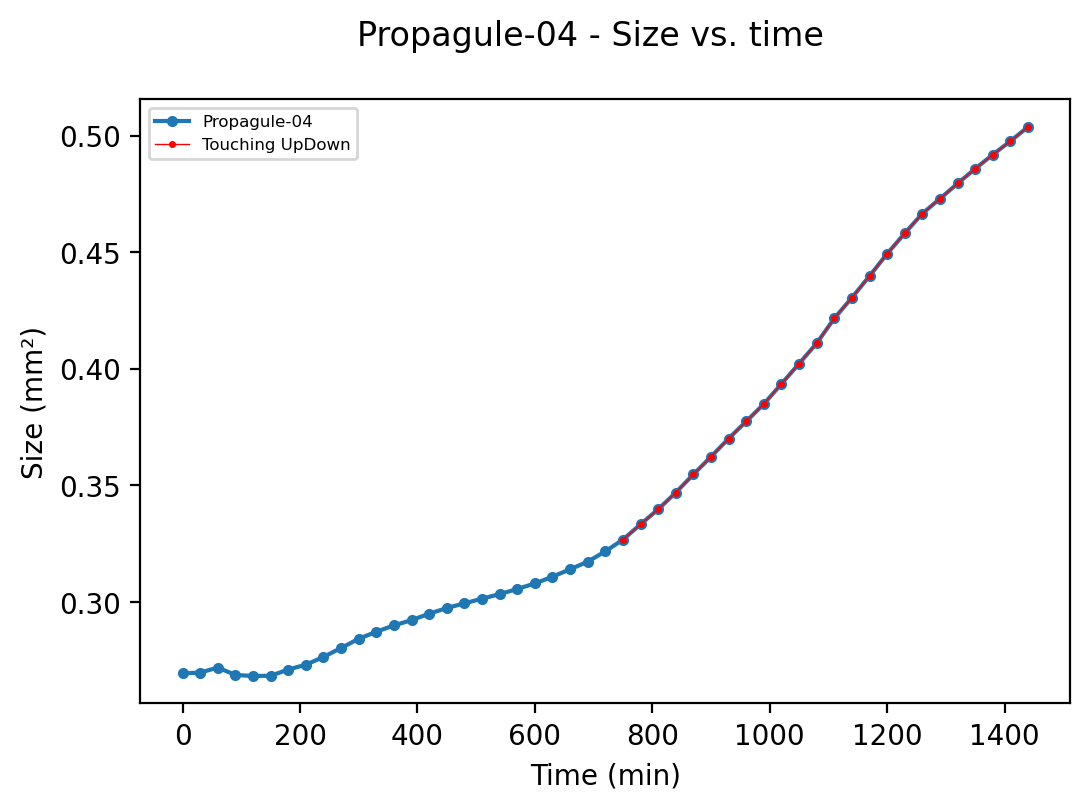

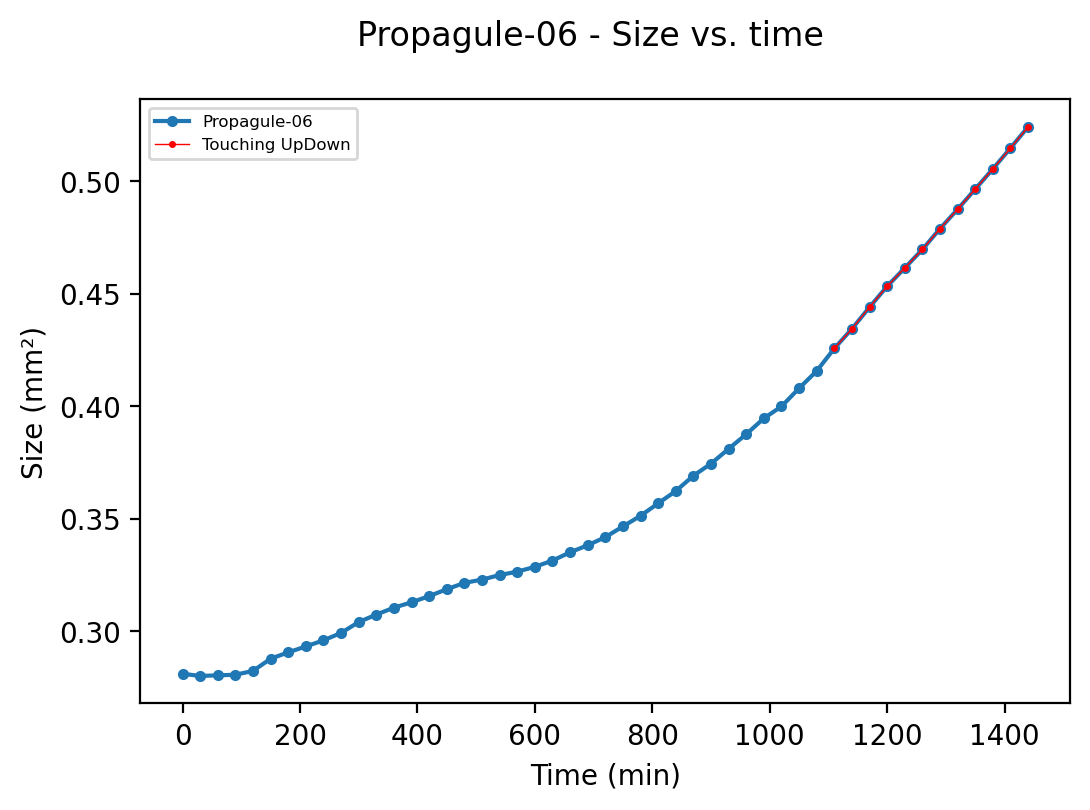

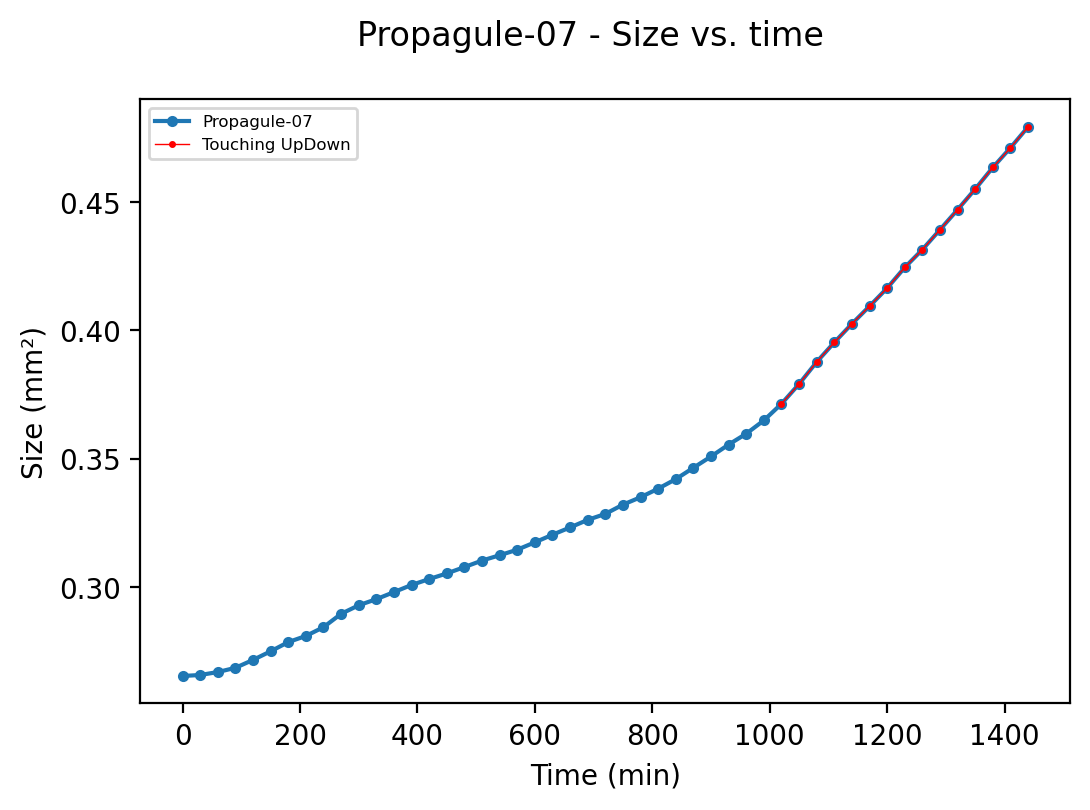

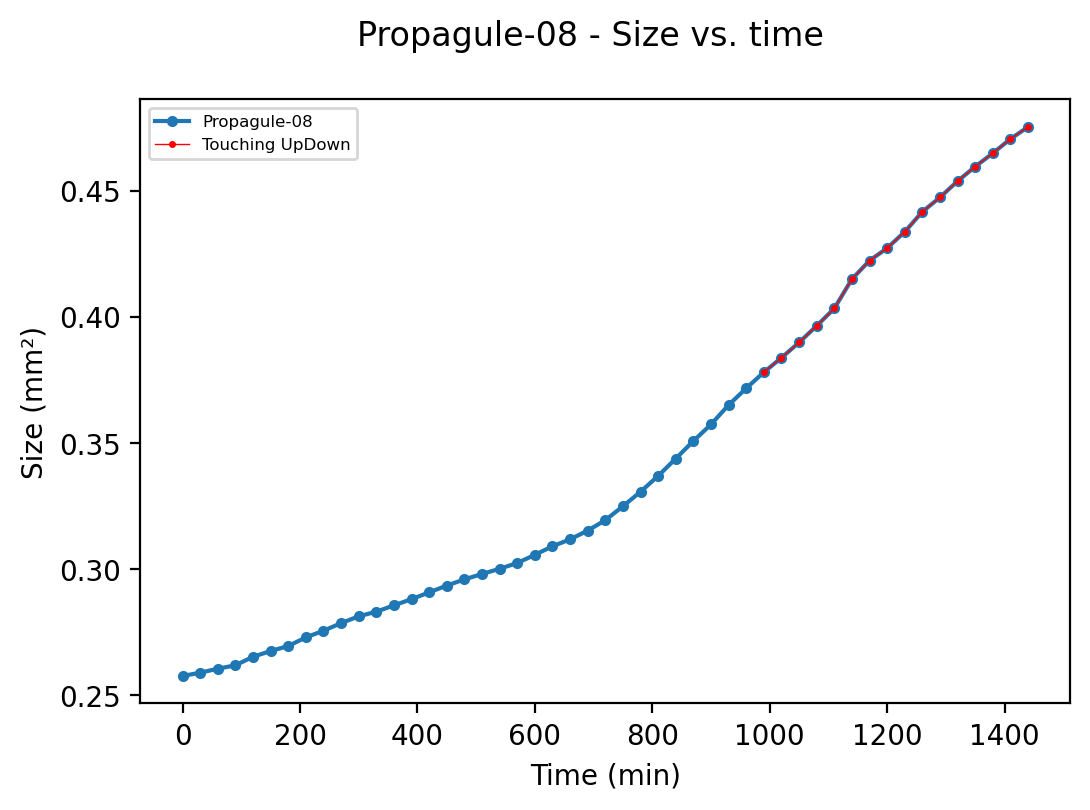

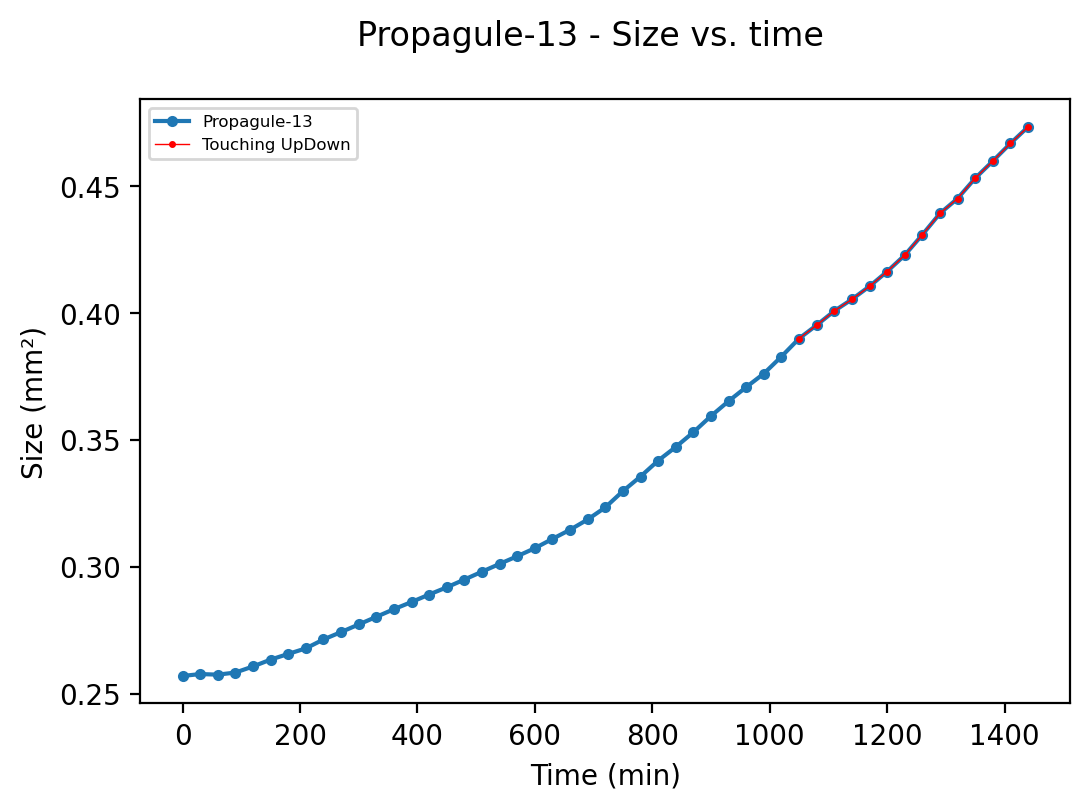

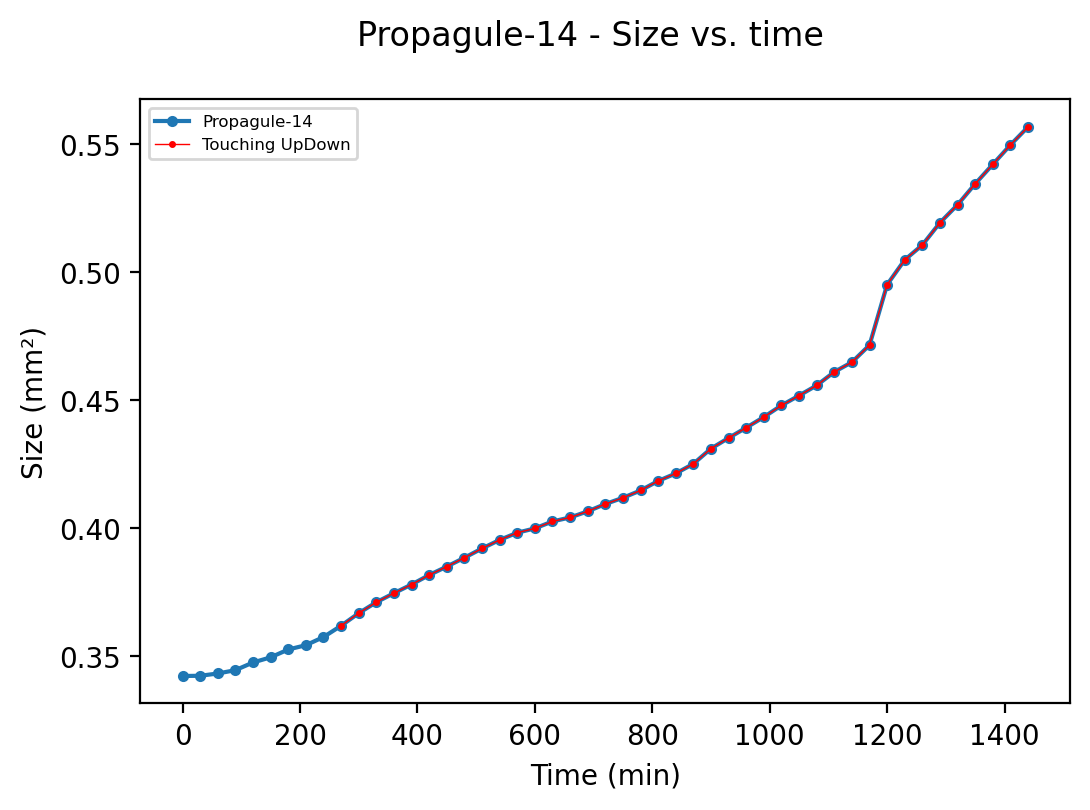

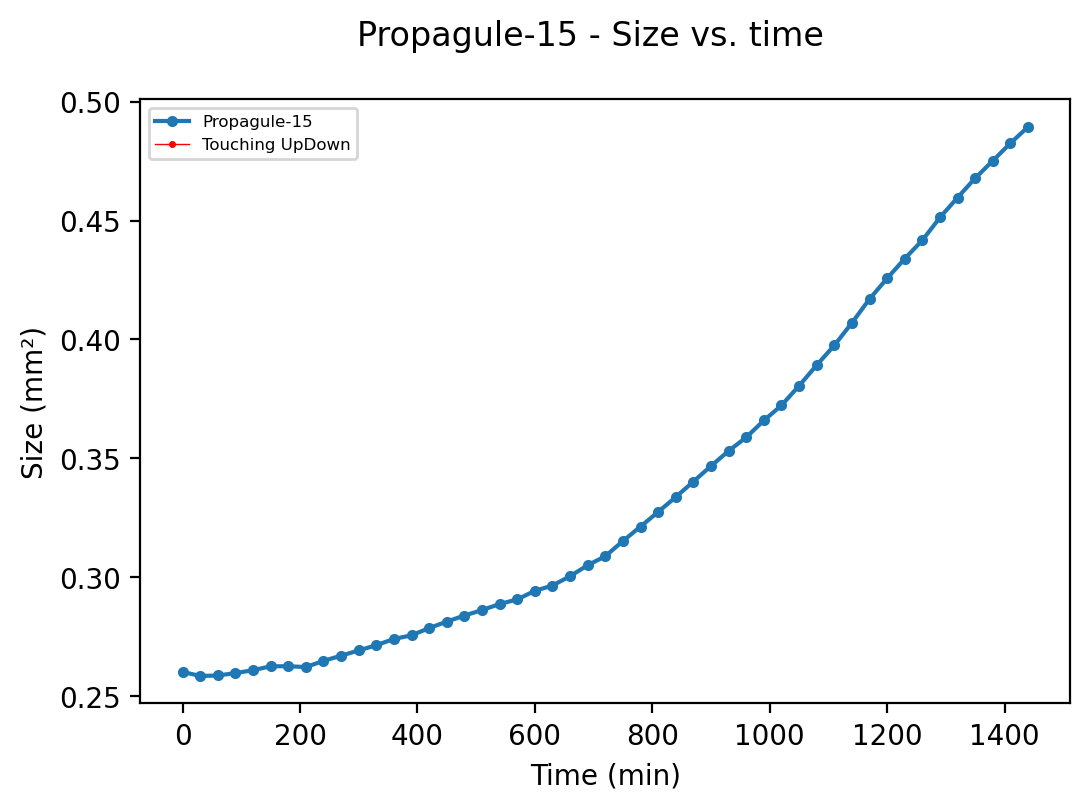

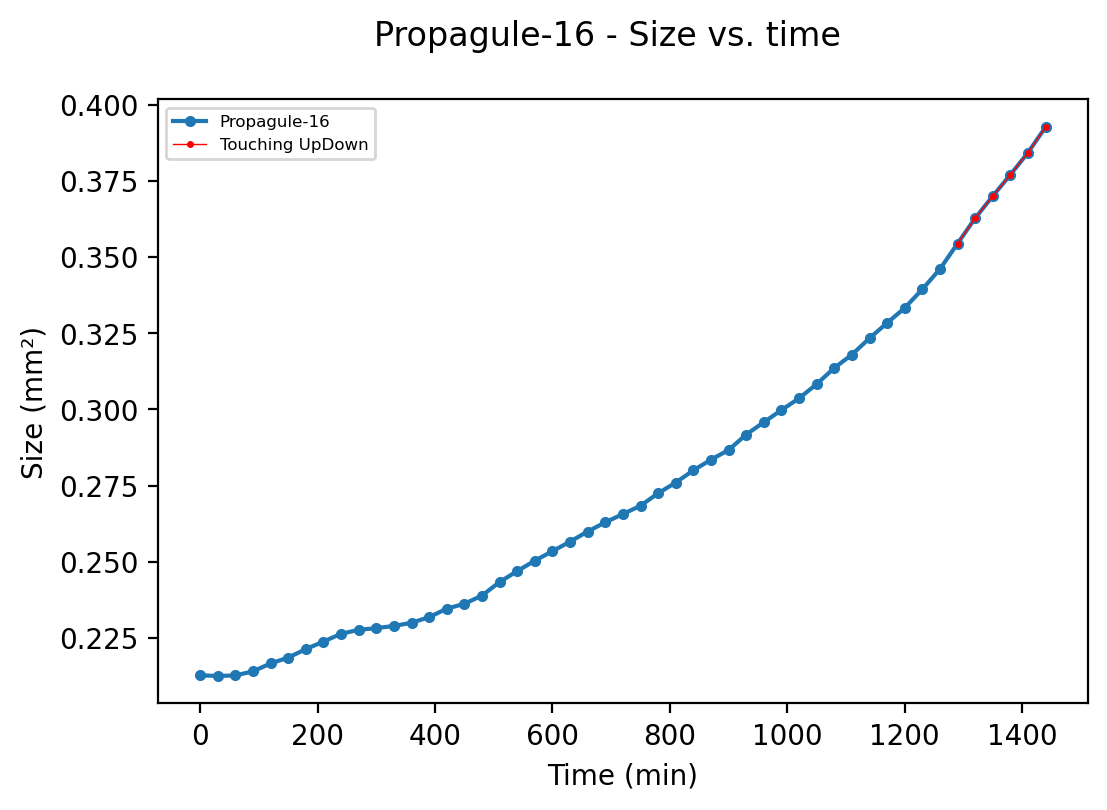

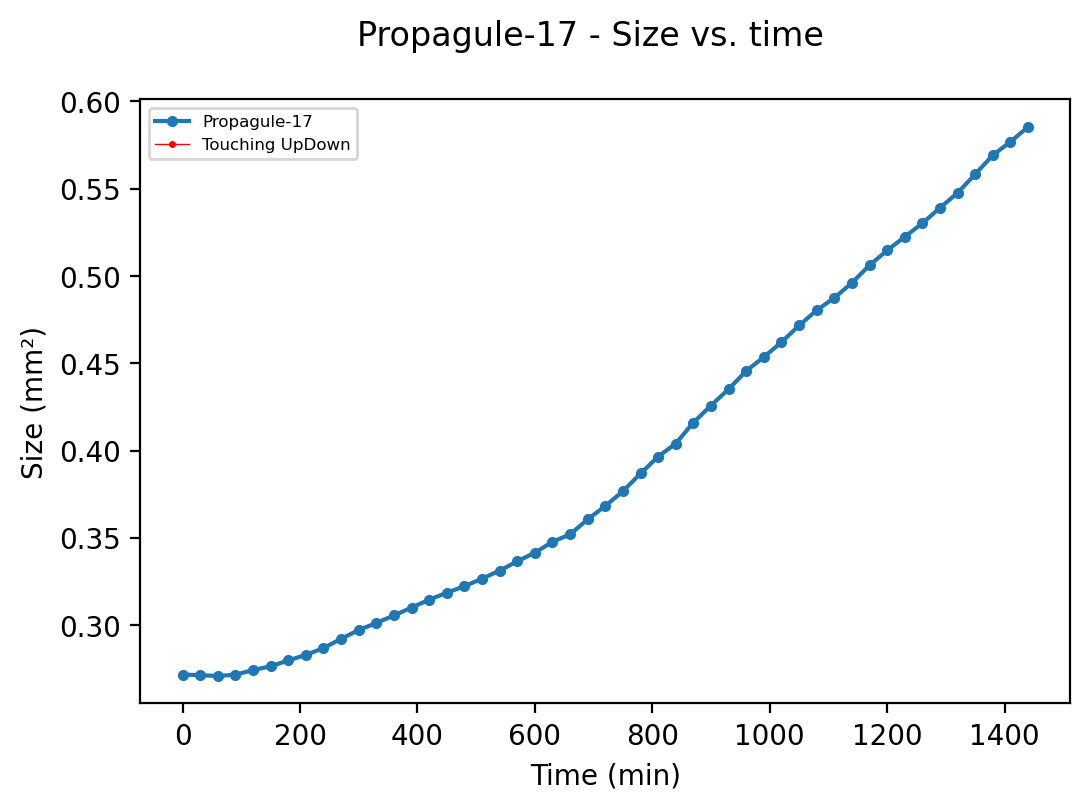

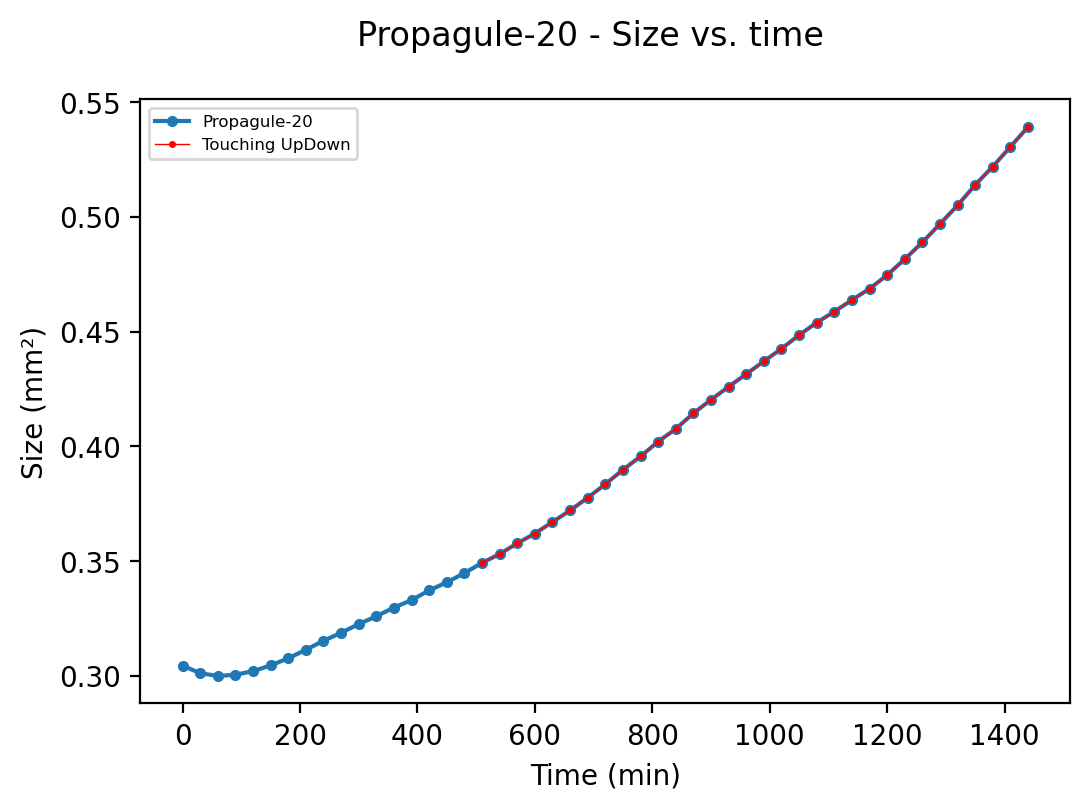

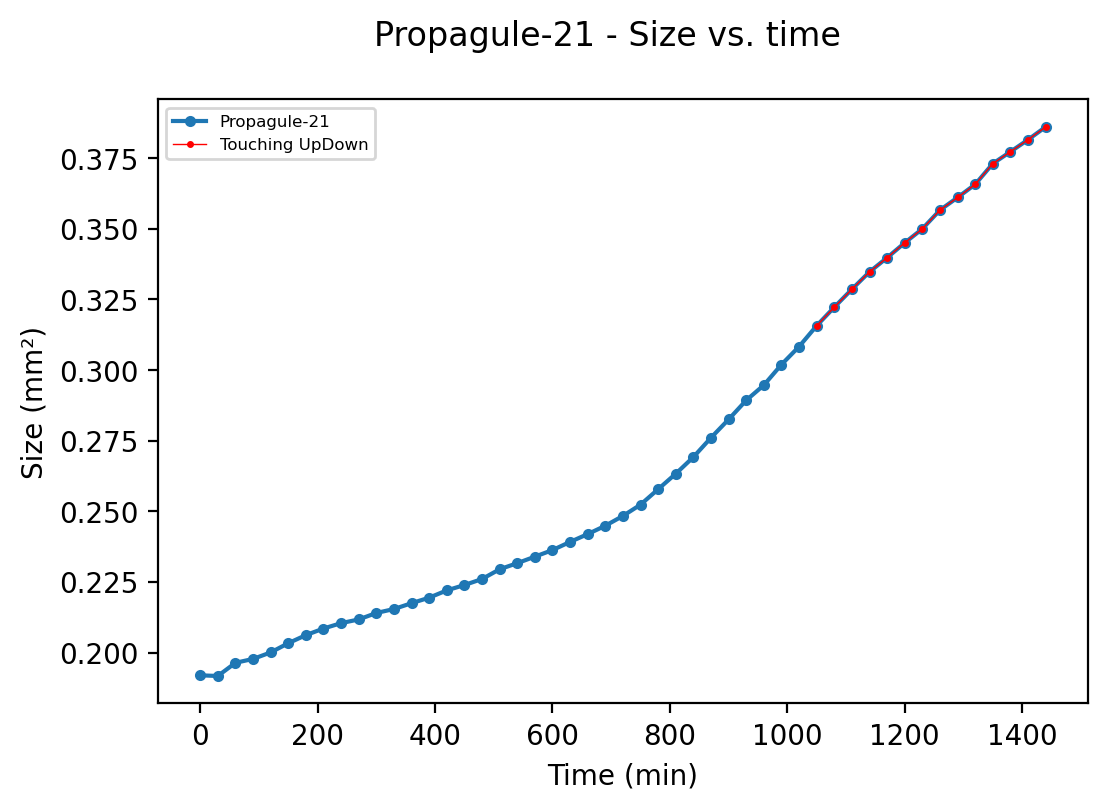

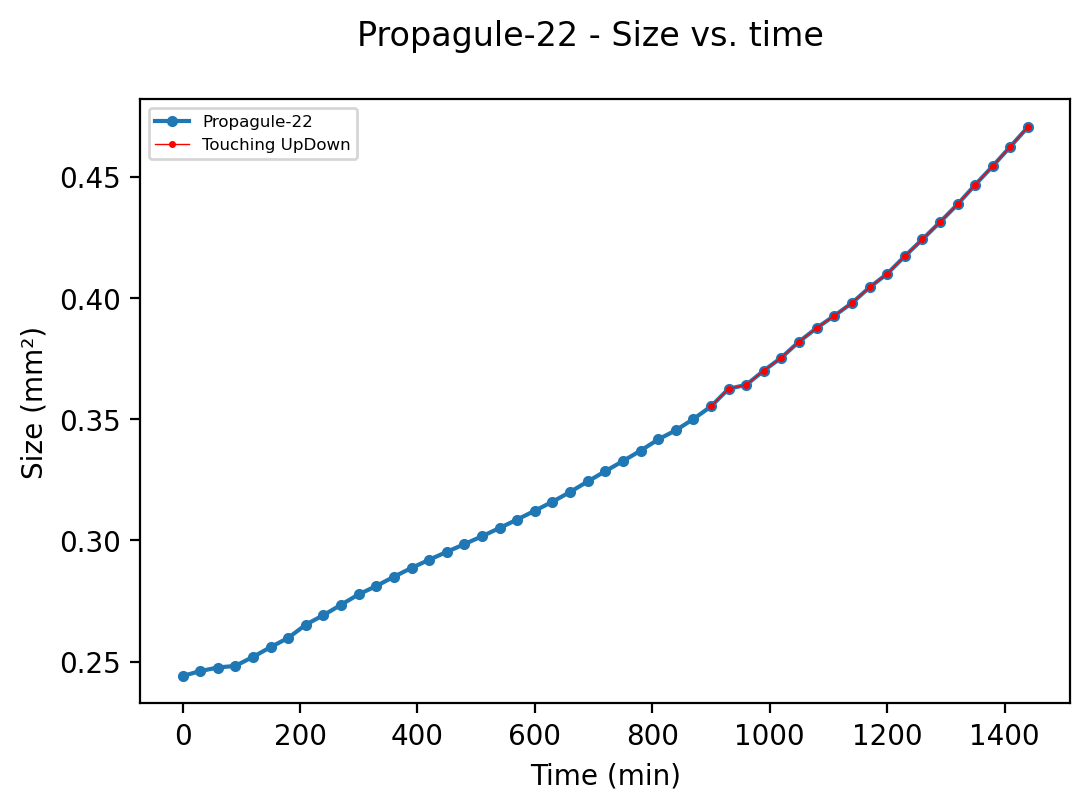

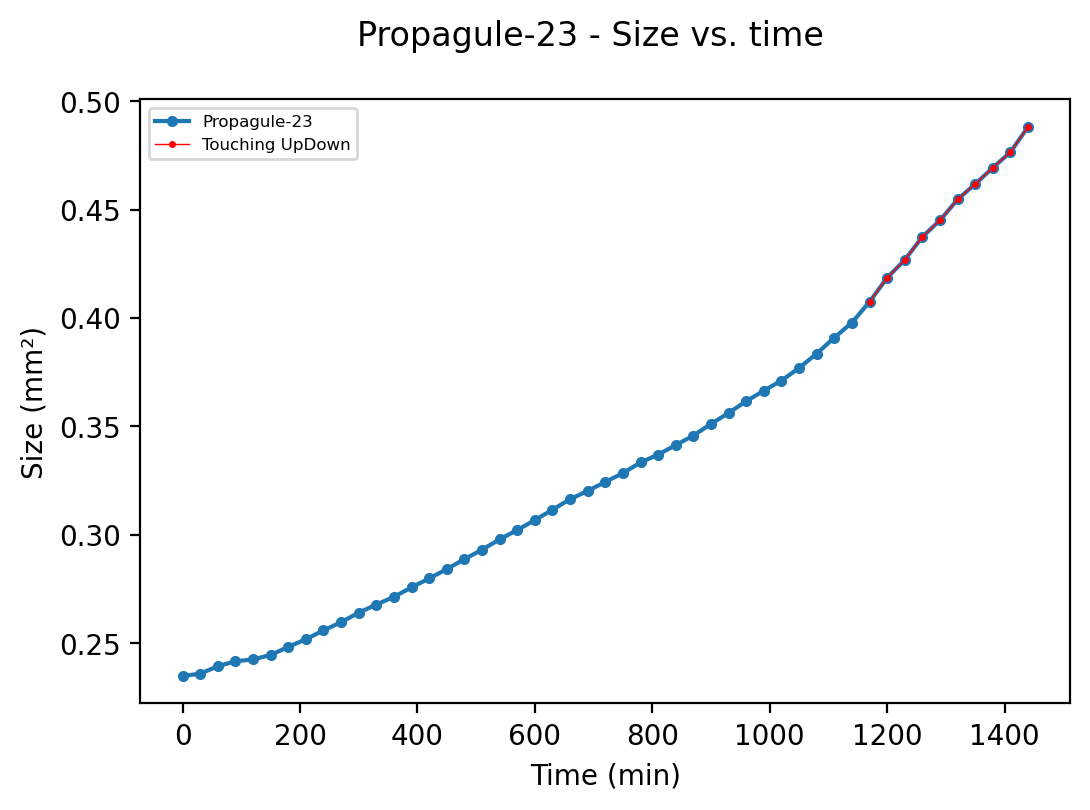

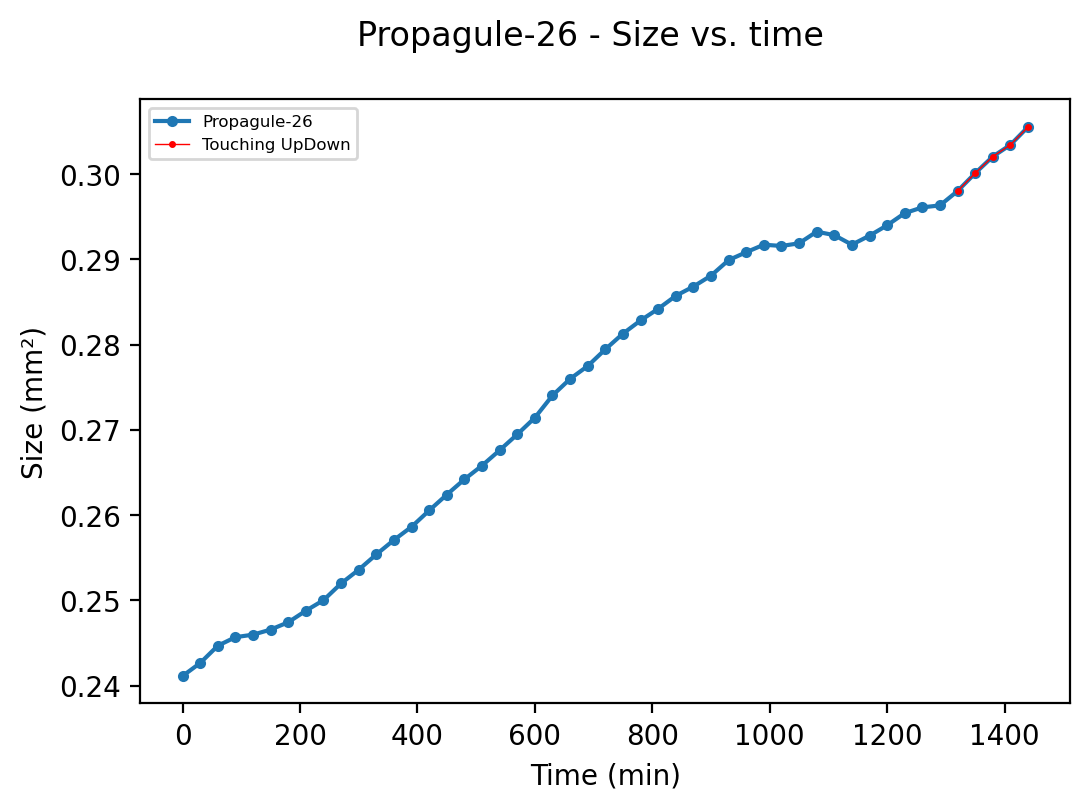

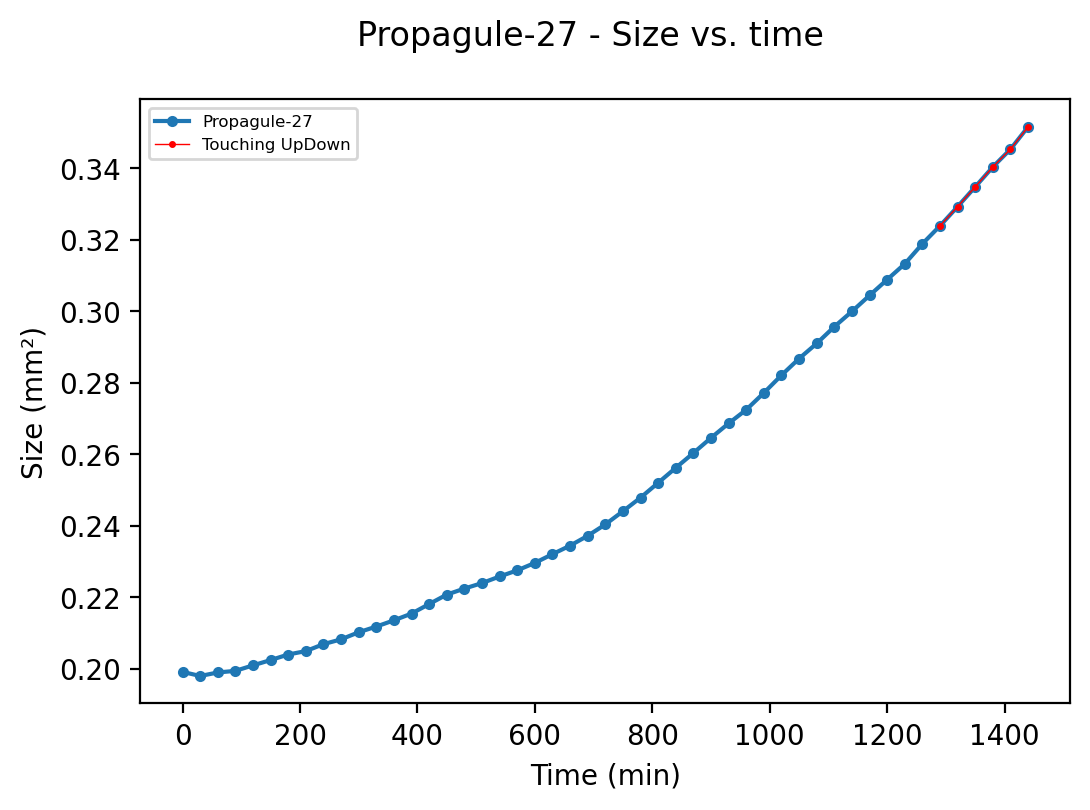

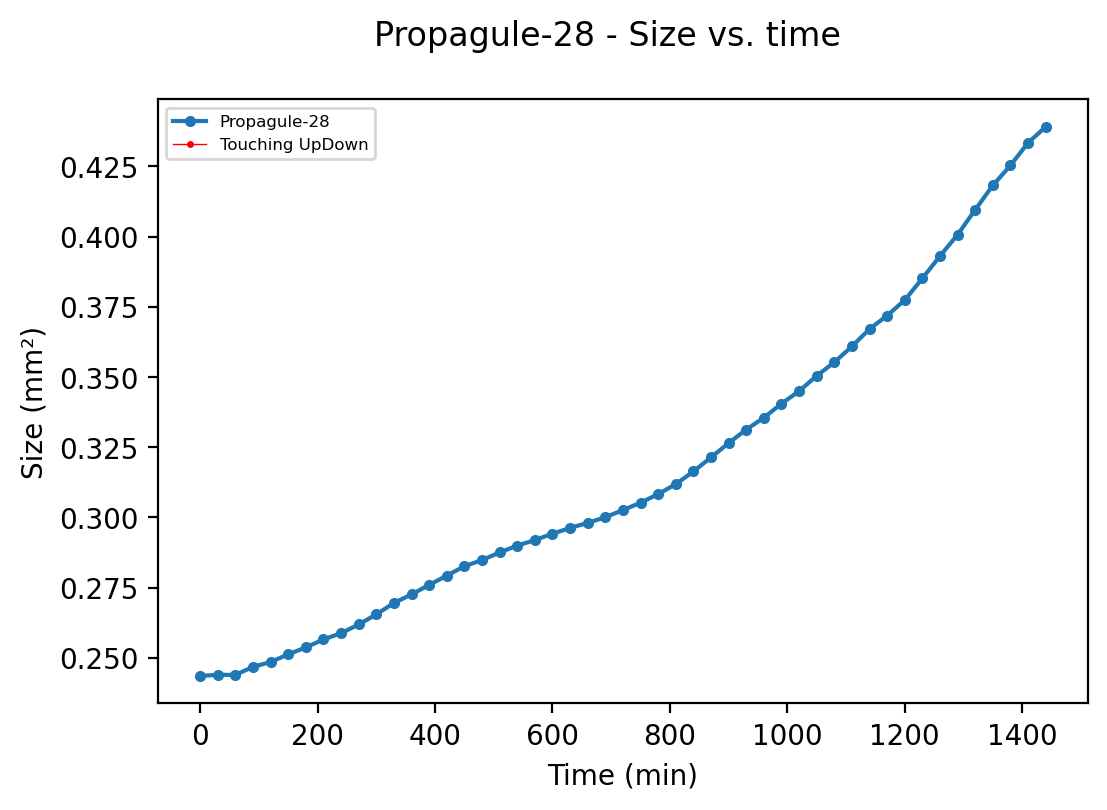

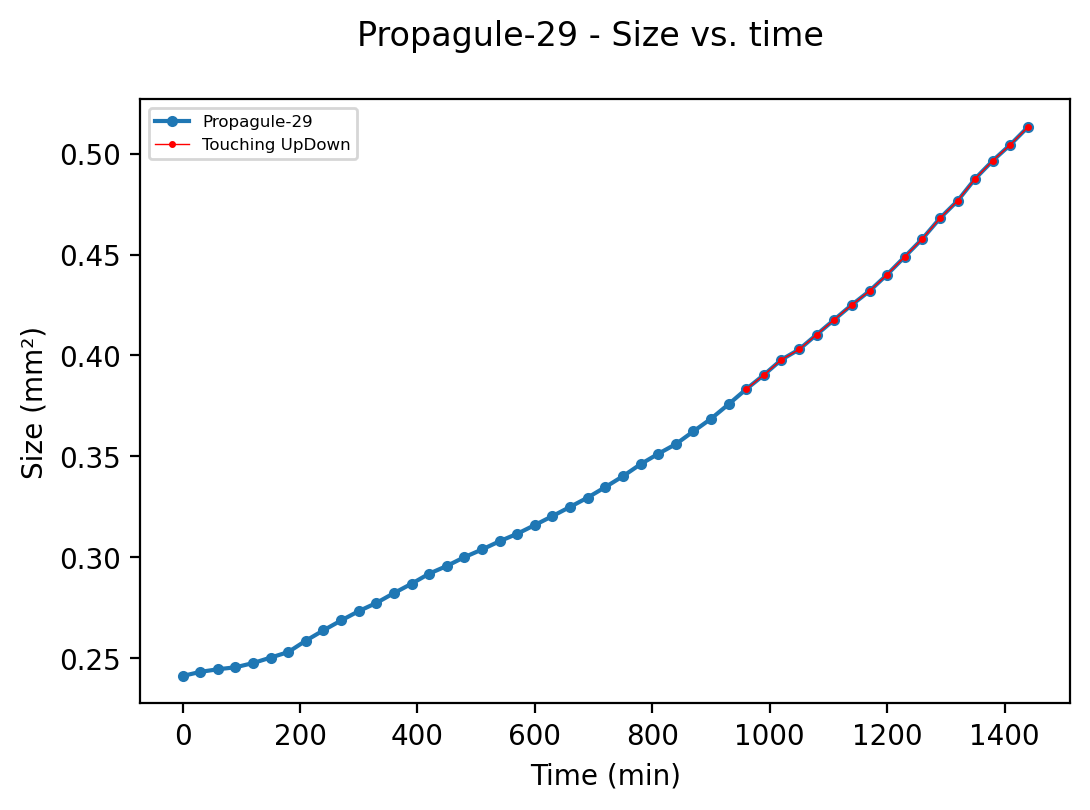

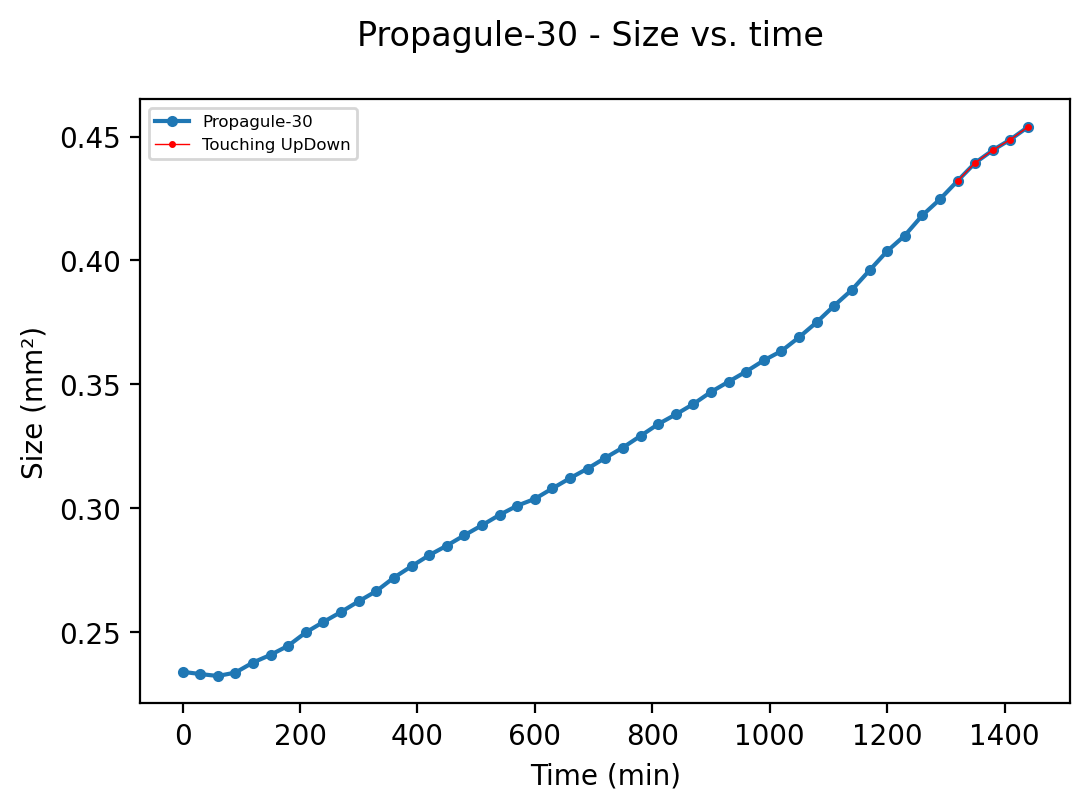

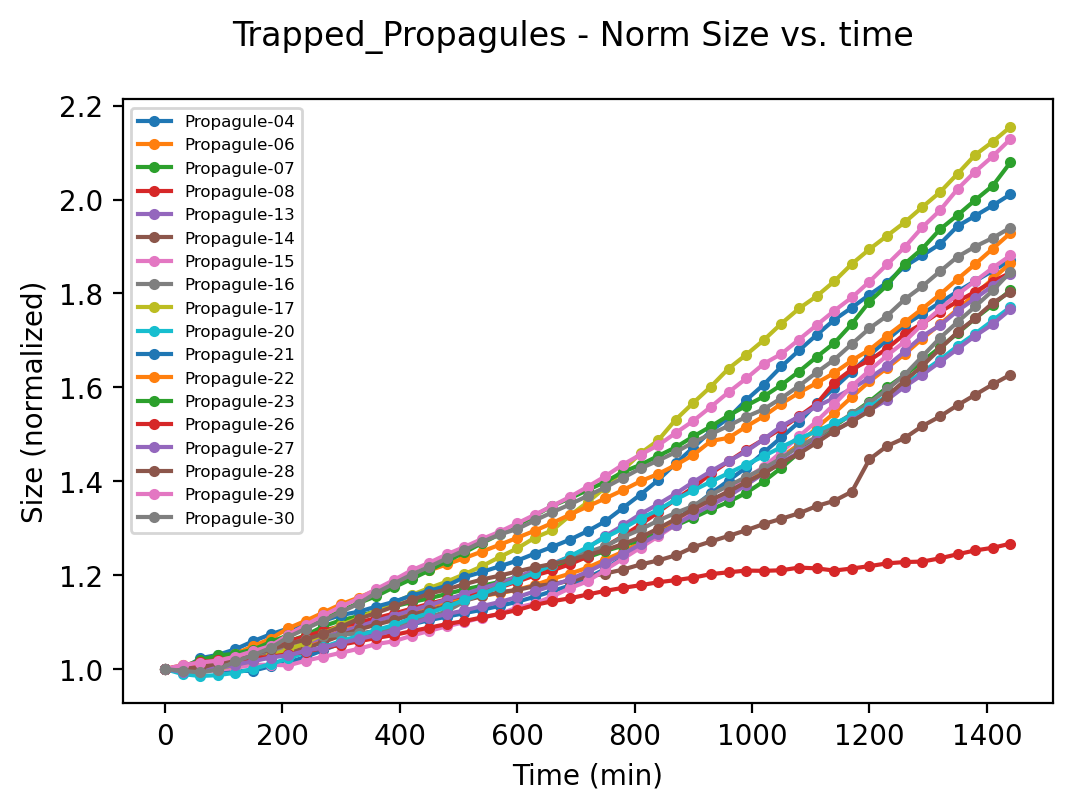

In [9]:
# plot result

#PlotResults(StackListFree, DataFree, P, 'Free_Propagules', Trapped=False)

PlotResults(StackListTrapped, DataTrapped, P, 'Trapped_Propagules', Trapped=True) 

# Test Zone

In [14]:
DataFree

,Time (min),Size (mm²),Normalized Size,Height(µm),Bounding box (px)
Propagule-03,"[0.0, 30.0, 60.0, 90.0, 120.0, 150.0, 180.0, 2...","[0.2156504, 0.2153672, 0.21551151999999998, 0....","[1.0, 0.9986867633911183, 0.999355994702537, 0...","[540.8, 539.6, 538.8, 537.6, 540.0, 541.6, 543...","[[346.0, 540.0, 1698.0, 1867.0], [354.0, 566.0..."
Propagule-09,"[0.0, 30.0, 60.0, 90.0, 120.0, 150.0, 180.0, 2...","[0.26096848, 0.260452, 0.26135152, 0.263677599...","[1.0, 0.9980209104179938, 1.001467763463235, 1...","[563.6, 565.6, 562.0, 560.0, 569.2, 566.8, 573...","[[410.0, 601.0, 1819.0, 2155.0], [409.0, 605.0..."
Propagule-12,"[0.0, 30.0, 60.0, 90.0, 120.0, 150.0, 180.0, 2...","[0.28049632, 0.2810208, 0.28230256, 0.28283328...","[1.0, 1.0018698284526513, 1.006439442770586, 1...","[648.0, 650.0, 652.0, 652.0, 653.6, 656.0, 661...","[[492.0, 982.0, 2112.0, 2509.0], [491.0, 985.0..."
Propagule-18,"[0.0, 30.0, 60.0, 90.0, 120.0, 150.0, 180.0, 2...","[0.29671184, 0.29868944000000003, 0.29989376, ...","[1.0, 1.0066650525304282, 1.010723940102963, 1...","[687.6, 688.4, 690.0, 692.0, 696.4, 699.2, 703...","[[344.0, 734.0, 2063.0, 2156.0], [346.0, 736.0..."
Propagule-19,"[0.0, 30.0, 60.0, 90.0, 120.0, 150.0, 180.0, 2...","[0.27397296000000004, 0.27358704, 0.2739129600...","[1.0, 0.9985913938368223, 0.9997810002855756, ...","[613.2, 614.0, 614.8, 615.2, 617.6, 619.2, 622...","[[401.0, 424.0, 1934.0, 1898.0], [401.0, 430.0..."
Propagule-24,"[0.0, 30.0, 60.0, 90.0, 120.0, 150.0, 180.0, 2...","[0.21268448, 0.21285279999999998, 0.21353424, ...","[1.0, 1.000791407064587, 1.0039954020152293, 1...","[521.6, 520.4, 519.6, 521.6, 526.4, 527.6, 530...","[[500.0, 650.0, 1804.0, 2018.0], [504.0, 653.0..."
Propagule-25,"[0.0, 30.0, 60.0, 90.0, 120.0, 150.0, 180.0, 2...","[0.29807568, 0.2983, 0.29976576, 0.30189296000...","[1.0, 1.0007525605577752, 1.0056699694520532, ...","[613.6, 612.4, 612.4, 614.0, 617.6, 630.0, 658...","[[487.0, 721.0, 2021.0, 2339.0], [491.0, 725.0..."


In [10]:
np.zeros([2,8])


array([[0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.]])